# Projections et composantes principales - KMAXPP05

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

## Projection interactive

In [2]:
style = {'description_width': 'initial'}
layout_slider = widgets.Layout(width='300px')

s_x1 = widgets.FloatSlider(min=-5, max=5, step=0.1, value=1.5, description='$x_1$ :', style=style, layout=layout_slider)
s_x2 = widgets.FloatSlider(min=-5, max=5, step=0.1, value=1, description='$x_2$ :', style=style, layout=layout_slider)
s_angle = widgets.FloatSlider(min=0, max=360, step=1, value=8, description='Angle de $u$ (°):', style=style, layout=layout_slider)

out = widgets.Output(layout=widgets.Layout(height='750px', border='2px solid #3498db', border_radius='10px', padding='10px'))

def update_plot(x1, x2, angle_deg):
    theta = np.radians(angle_deg)
    u = np.array([np.cos(theta), np.sin(theta)])
    X = np.array([x1, x2])
    
    z = np.dot(X, u)
    x_hat = z * u
    
    with out:
        clear_output(wait=True)
        # On force l'utilisation du moteur interne de Matplotlib (MathText) pour éviter les dépendances externes
        plt.rcParams['text.usetex'] = False 
        
        fig, ax = plt.subplots(figsize=(8, 8))

        # 1. Droite D
        line_len = 10
        ax.plot([-u[0]*line_len, u[0]*line_len], [-u[1]*line_len, u[1]*line_len], 
                color='gray', linestyle='--', alpha=0.3, label=r'Droite $D$ (Axe Principal)')

        # 2. Vecteur O -> X
        ax.quiver(0, 0, X[0], X[1], color='black', angles='xy', scale_units='xy', scale=1, alpha=0.2)
        ax.scatter(X[0], X[1], color='black', s=60, zorder=5, label=rf'$X$ ({x1:.1f}, {x2:.1f})')

        # 3. Vecteur u
        ax.quiver(0, 0, u[0], u[1], color='blue', angles='xy', scale_units='xy', scale=1, 
                  width=0.01, label=r'Vecteur $u$ (unitaire)', zorder=10)

        # 4. Vecteur O -> Ĥ (Le Projeté)
        ax.quiver(0, 0, x_hat[0], x_hat[1], color='#2ecc71', angles='xy', scale_units='xy', scale=1, 
                  width=0.015, label=rf'Projeté $\hat{{X}}$ ($Z$={z:.2f})')
        ax.scatter(x_hat[0], x_hat[1], color='#2ecc71', s=100, edgecolors='black', zorder=6)

        # 5. Vecteur Erreur (X_hat -> X)
        ax.quiver(x_hat[0], x_hat[1], X[0]-x_hat[0], X[1]-x_hat[1], 
                  color='#e74c3c', angles='xy', scale_units='xy', scale=1, alpha=0.8, label=r'Erreur ($X - \hat{X}$)')

        # 6. Ligne de rappel
        ax.plot([X[0], x_hat[0]], [X[1], x_hat[1]], color='black', linestyle=':', linewidth=1.5)

        # Habillage
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
        ax.axvline(0, color='black', linewidth=0.8, alpha=0.4)
        ax.set_aspect('equal')
        ax.grid(True, linestyle='--', alpha=0.5)
        # ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=10)
        ax.legend(loc='lower right', fontsize=10)
        
        # Le bloc texte informatif (on utilise rf"" et {{ }} pour les accolades LaTeX)
        info_text = (rf"Score $Z = X \cdot u = {z:.3f}$" + "\n" +
                     rf"$\hat{{X}} = Z \cdot u^T = [{x_hat[0]:.2f}, {x_hat[1]:.2f}]$")
        
        ax.text(-1.90, 1.65, info_text, fontsize=12, family='serif',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='#3498db', boxstyle='round,pad=0.5'))

        plt.title(r"Visualisation Géométrique : Projection $\hat{X}$", fontsize=15, pad=20)
        plt.show()

interactive_plot = widgets.interactive_output(update_plot, {
    'x1': s_x1, 'x2': s_x2, 'angle_deg': s_angle
})

ui = widgets.VBox([
    # widgets.HTML("<h2 style='text-align:center; color:#2980b9;'>Simulateur de Projection</h2>"),
    widgets.HBox([s_x1, s_x2, s_angle], layout=widgets.Layout(justify_content='center')),
    out
])

display(ui)

## Différence entre projection et régression

In [3]:
np.random.seed(13)

In [4]:
n = 10
mu = np.array([0., 0.])
cov = np.array([[1., 0.7], [0.7, 1.0]])
x = sp.stats.multivariate_normal(mu, cov).rvs(n)
x = (x - x.mean(axis=0)) / x.std(axis=0)

In [5]:
corr_matrix = np.cov(x, rowvar=False, ddof=0)

In [6]:
x1 = x[:,[0]]
x2 = x[:,[1]]

In [7]:
# Calcul de la droite de régression
beta_hat = np.linalg.inv(x1.T @ x1) @ x1.T @ x2

In [8]:
# Calcul de la composante principale
valeurs_propres, vecteurs_propres = np.linalg.eig(corr_matrix)
u = vecteurs_propres[:,[np.argmax(valeurs_propres)]]

In [9]:
vecteurs_propres

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

In [10]:
xi = np.linspace(min(x1.min() - 0.1, -2.0), max(x1.max() + 0.1, 2.0), 100).reshape(-1, 1)
yi = xi @ beta_hat
yh = x1 @ beta_hat

In [11]:
x_hat = x @ u @ u.T

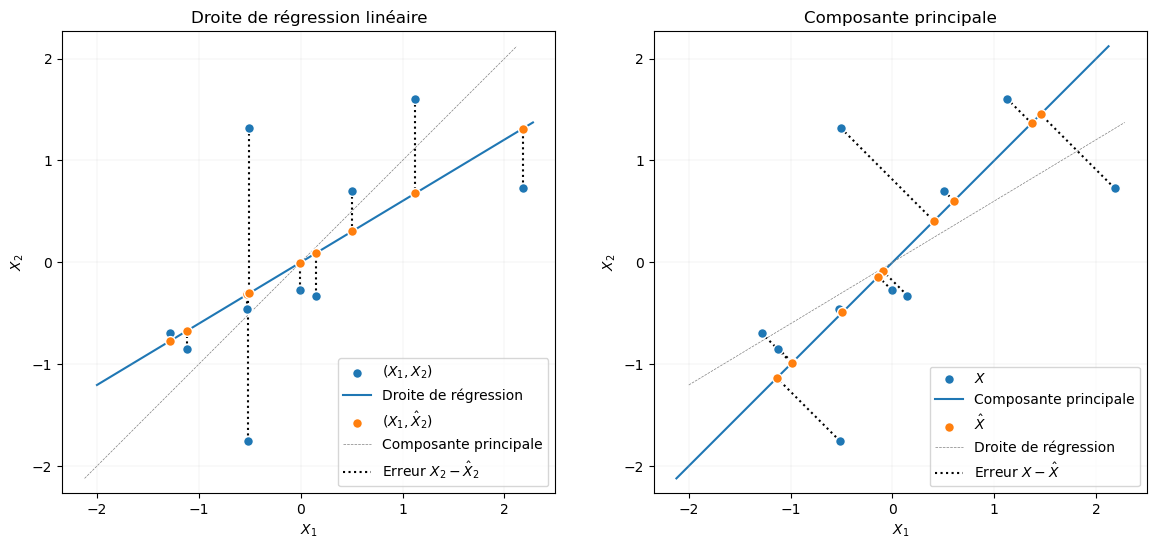

In [12]:
length = 3.0
plt.figure(figsize=(14, 6))
plt.subplot(121)
plt.scatter(x[:,0], x[:,1], edgecolor="w", s=50, lw=1, zorder=1, label=r"$(X_1, X_2)$");
plt.plot(xi, yi, zorder=0, label="Droite de régression");
plt.scatter(x1, yh, edgecolor="w", s=50, lw=1, zorder=2, label=r"$(X_1, \hat{X}_2)$");
plt.plot([-u[0] * length, u[0] * length], [-u[1] * length, u[1] * length], zorder=0, color="grey", ls="--", lw=0.5, label="Composante principale")
label = r"Erreur $X_2 - \hat{X}_2$"
for _x1, _x2, _x2h in zip(x1, x2, yh):
    plt.plot([_x1, _x1], [_x2, _x2h], ls=":", color="k", zorder=0, label=label)
    label = None
plt.grid(lw=0.1)
plt.legend(loc="lower right")
plt.axis("equal")
plt.xlabel(r"$X_1$")
plt.ylabel(r"$X_2$")
plt.title("Droite de régression linéaire")
plt.subplot(122)
plt.scatter(x[:,0], x[:,1], edgecolor="w", s=50, lw=1, zorder=1, label=r"$X$");
plt.plot([-u[0] * length, u[0] * length], [-u[1] * length, u[1] * length], zorder=0, label="Composante principale")
plt.scatter(x_hat[:,0], x_hat[:,1], edgecolor="w", s=50, lw=1, zorder=2, label=r"$\hat{X}$")
plt.plot(xi, yi, zorder=0, color="grey", ls="--", lw=0.5, label="Droite de régression");
label = r"Erreur $X - \hat{X}$"
for _x, _xh in zip(x, x_hat):
    plt.plot([_x[0], _xh[0]], [_x[1], _xh[1]], ls=":", color="k", zorder=0, label=label)
    label = None
plt.grid(lw=0.1)
plt.axis("equal")
plt.legend(loc="lower right")
plt.xlabel(r"$X_1$")
plt.ylabel(r"$X_2$")
plt.title("Composante principale");

## Différence entre projection et régression (interactif)

In [13]:
# Nous utilisons un dictionnaire global pour stocker la "mémoire" de l'animation.
# Cela nous permet de conserver les mêmes données X quand on change juste l'angle,
# et de changer de seed seulement quand on clique sur le bouton "Observer".
global_state = {
    'X': None,
    'corr_matrix': None,
    'current_seed': 13,
    'cov_ref_for_X': 0.7 # Pour savoir si X a été généré avec la covariance du slider
}

In [14]:
def update_visualization(cov_val, manual_angle_deg, _trigger):
    """
    Fonction principale appelée à chaque mouvement de slider ou clic de bouton.
    Elle recalcule la régression et la projection manuelle, puis trace les graphes.
    """
    clear_output_for_new_plot = True # Indique à matplotlib d'effacer le graphe précédent
    
    # -- A. Gestion de la génération des données X --
    # On régénère X uniquement si :
    # 1. C'est le premier lancement (X est None)
    # 2. L'angle manuel est 0 (indique un reset ou un nouveau tirage de X via un hack du slider)
    # 3. La covariance a changé (on doit recréer un nuage cohérent)
    
    should_regenerate = (global_state['X'] is None) or (cov_val != global_state['cov_ref_for_X'])
    if should_regenerate:
        np.random.seed(global_state['current_seed'])
        n = 10
        mu = np.array([0., 0.])
        cov_matrix = np.array([[1., cov_val], [cov_val, 1.0]])
        raw_x = sp.stats.multivariate_normal(mu, cov_matrix).rvs(n)
        # Standardisation (comme dans ton code original)
        X_standardized = (raw_x - raw_x.mean(axis=0)) / raw_x.std(axis=0)
        global_state['X'] = X_standardized
        global_state['cov_ref_for_X'] = cov_val
        global_state['corr_matrix'] = np.cov(X_standardized, rowvar=False, ddof=0)
        
    X = global_state['X']
    corr_matrix = global_state['corr_matrix']
    x1 = X[:,[0]]
    x2 = X[:,[1]]

    # -- B. Calcul de la régression OLS (Automatique) --
    beta_hat = np.linalg.inv(x1.T @ x1) @ x1.T @ x2
    xi = np.linspace(min(x1.min() - 0.1, -2.0), max(x1.max() + 0.1, 2.0), 100).reshape(-1, 1)
    yi_regression = xi @ beta_hat
    x2h_regression_pred = x1 @ beta_hat

    # -- C. Calcul de la projection sur l'angle manuel (Slider) --
    # On convertit l'angle en vecteur unitaire u_man
    theta_rad = np.radians(manual_angle_deg)
    u_man = np.array([[np.cos(theta_rad)], [np.sin(theta_rad)]])
    
    # Coordonnées des projetés sur l'axe u_man
    x_hat_man = X @ u_man @ u_man.T
    z = X @ u_man
    var_z = np.var(z, ddof=0)
    
    # Calcul de la "vraie" CP1 (pour info et pour la ligne en pointillés)
    valeurs_propres, vecteurs_propres = np.linalg.eig(corr_matrix)
    u_true = vecteurs_propres[:,[np.argmax(valeurs_propres)]]

    # -- D. TRACÉ DES GRAPHES --
    # On prépare la figure
    if clear_output_for_new_plot:
        plt.close('all') # Ferme les figures précédentes pour éviter la surconsommation de mémoire
        
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    length_axis = 3.0
    
    # ---- Subplot 1: Régression Linéaire ----
    ax = axs[0]
    # Observations originales
    ax.scatter(X[:,0], X[:,1], edgecolor="w", s=50, lw=1, zorder=1, label=r"Obs. $(X_1, X_2)$");
    # Droite de régression (la "vraie" solution OLS)
    ax.plot(xi, yi_regression, zorder=0, label="Droite de régression (OLS)");
    # Prédictions de régression sur la droite
    ax.scatter(x1, x2h_regression_pred, edgecolor="w", s=50, lw=1, zorder=2, label=r"Préd. $(X_1, \hat{X}_2)$");
    # Trace les résidus verticaux (Erreur X2 - X2h)
    label_err_reg = r"Erreur verticale $X_2 - \hat{X}_2$"
    for _x1, _x2, _x2h in zip(x1, x2, x2h_regression_pred):
        ax.plot([_x1, _x1], [_x2, _x2h], ls=":", color="k", zorder=0, label=label_err_reg)
        label_err_reg = None # Pour ne pas répéter dans la légende
        
    # Info visuelle : Vraie composante principale (en pointillés)
    ax.plot([-u_true[0] * length_axis, u_true[0] * length_axis], [-u_true[1] * length_axis, u_true[1] * length_axis], 
            zorder=-1, color="grey", ls="--", lw=0.5, label="Vraie CP1 (Référence)")
    
    ax.grid(lw=0.1)
    ax.legend(loc="lower right")
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel(r"$X_1$")
    ax.set_ylabel(r"$X_2$")
    ax.set_title(f"Régression Linéaire (Minimisation verticale)\nPente OLS: {beta_hat[0][0]:.2f}")

    # ---- Subplot 2: Projection / Composante Principale ----
    ax = axs[1]
    # Observations originales
    ax.scatter(X[:,0], X[:,1], edgecolor="w", s=50, lw=1, zorder=1, label=r"Obs. $X$");
    # L'axe de projection défini par l'angle manuel
    ax.plot([-u_man[0] * length_axis, u_man[0] * length_axis], [-u_man[1] * length_axis, u_man[1] * length_axis], 
            zorder=0, label="Axe de projection (Slider)")
    # Les points projetés sur l'axe
    ax.scatter(x_hat_man[:,0], x_hat_man[:,1], edgecolor="w", s=50, lw=1, zorder=2, label=r"Projetés $\hat{X}$")
    # Trace les résidus orthogonaux (Erreur X - Xh)
    label_err_pca = r"Erreur orthogonale $X - \hat{X}$"
    for _x, _xh in zip(X, x_hat_man):
        ax.plot([_x[0], _xh[0]], [_x[1], _xh[1]], ls=":", color="k", zorder=0, label=label_err_pca)
        label_err_pca = None # Pour ne pas répéter dans la légende
        
    # Info visuelle : Droite de régression (en pointillés)
    ax.plot(xi, yi_regression, zorder=-1, color="grey", ls="--", lw=0.5, label="Droite de régression (Référence)");

    # Info visuelle : Vraie composante principale (en pointillés)
    ax.plot([-u_true[0] * length_axis, u_true[0] * length_axis], [-u_true[1] * length_axis, u_true[1] * length_axis], 
            zorder=-1, color="blue", ls=":", lw=0.5, label="Vraie CP1 (Référence)")
    
    ax.grid(lw=0.1)
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc="lower right")
    ax.set_xlabel(r"$X_1$")
    ax.set_ylabel(r"$X_2$")
    ax.set_title(f"Projection sur axe manuel (Angle: {manual_angle_deg:.1f}°)\nVar[Z] = {var_z:.3f}")
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    
    plt.tight_layout()
    plt.show() # Force l'affichage du nouveau plot

# Slider 1: Covariance
slider_cov = widgets.FloatSlider(
    value=0.7, min=0.0, max=0.99, step=0.01,
    description='Covariance:',
    continuous_update=False, # Pour ne pas recalculer 100 fois en faisant glisser
    layout=widgets.Layout(width='50%')
)

# Slider 2: Angle manuel (pour la projection)
# On part de l'angle diagonal (45°), qui est une CP1 typique pour cov=0.7
slider_angle = widgets.FloatSlider(
    value=45, min=-90, max=90, step=1.0,
    description='Angle axe u (°):',
    continuous_update=True, # Update en direct pour voir la projection bouger
    layout=widgets.Layout(width='50%')
)

# Bouton: "Observer" pour re-générer X
button_observer = widgets.Button(
    description='Observer (Nouveau nuage)',
    button_style='info', # 'success', 'info', 'warning', 'danger' or ''
    layout=widgets.Layout(width='30%')
)

# Widget caché qui sert à "déclencher" la mise à jour quand on clique sur le bouton
# sans changer la valeur des sliders eux-mêmes.
btn_trigger = widgets.IntSlider(value=0, layout=widgets.Layout(visibility='hidden'))

def on_observer_clicked(b):
    """Handler du clic bouton: change de seed et incrémente le trigger."""
    global_state['current_seed'] = np.random.randint(0, 100000) # Nouveau seed aléatoire
    global_state['X'] = None
    btn_trigger.value += 1 # Cela force interactive_output à relancer update_visualization

button_observer.on_click(on_observer_clicked)

# Lien entre les widgets et la fonction de mise à jour
ui_output = widgets.interactive_output(
    update_visualization,
    {
        'cov_val': slider_cov,
        'manual_angle_deg': slider_angle,
        '_trigger': btn_trigger # Le trigger est passé comme argument mais ignoré par la fonction
    }
)
ui_output.layout.height = '550px'

# Layout: Bouton en haut, Sliders en ligne, Graphe en bas
# Nous utilisons un Layout flexbox pour organiser proprement l'interface.
control_layout = widgets.VBox([
    widgets.HBox([button_observer], layout=widgets.Layout(justify_content='center', padding='10px')),
    widgets.HBox([slider_cov, slider_angle], layout=widgets.Layout(justify_content='center'))
])

final_display = widgets.VBox([control_layout, ui_output])

# Affichage final dans le notebook
display(final_display)

## Changement de base

In [15]:
np.random.seed(13)

In [16]:
n = 10
mu = np.array([0., 0.])
cov = np.array([[1., 0.7], [0.7, 1.0]])
x = sp.stats.multivariate_normal(mu, cov).rvs(n)
x = (x - x.mean(axis=0)) / x.std(axis=0)

In [17]:
corr_matrix = np.cov(x, rowvar=False, ddof=0)

In [18]:
# Détermination des valeurs et vecteurs propres
valeurs_propres, vecteurs_propres = np.linalg.eig(corr_matrix)
tri = np.argsort(valeurs_propres)[-1::-1]
lbd = valeurs_propres[tri]
u = vecteurs_propres[:, tri]

In [19]:
z = x @ u

In [20]:
i = 8
j = 2
xh1 = x @ u[:,[0]] @ u[:,[0]].T
xh2 = x @ u[:,[1]] @ u[:,[1]].T

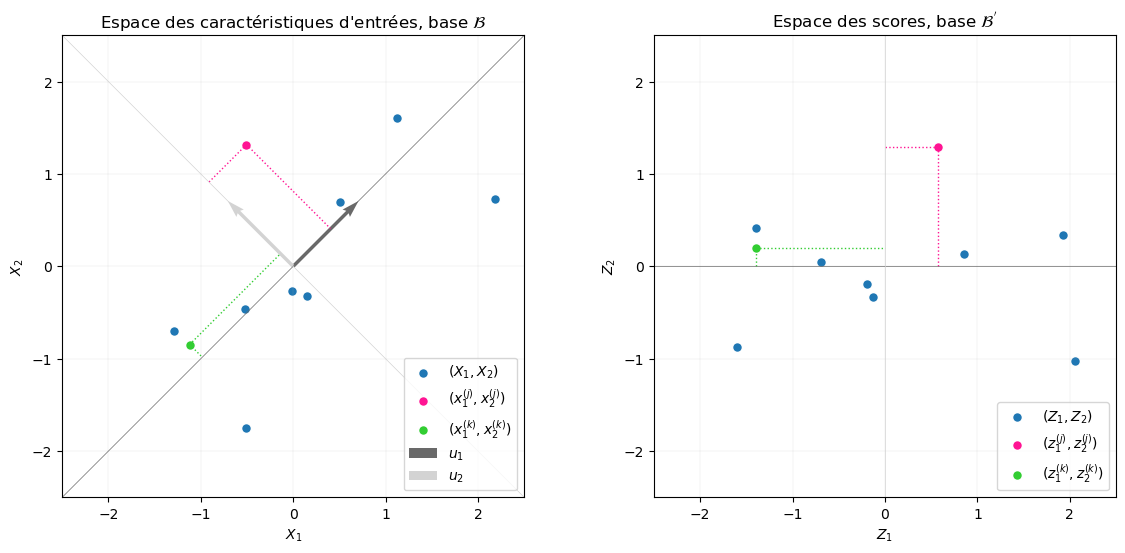

In [21]:
plt.figure(figsize=(14, 6))
plt.subplot(121)
plt.scatter(x[:,0], x[:,1], edgecolor="w", s=50, lw=1, zorder=1, label=r"$(X_1, X_2)$")
plt.scatter(x[[i],0], x[[i],1], edgecolor="w", s=50, lw=1, zorder=2, color="deeppink", label=r"$(x_1^{(j)}, x_2^{(j)})$")
plt.scatter(x[[j],0], x[[j],1], edgecolor="w", s=50, lw=1, zorder=2, color="limegreen", label=r"$(x_1^{(k)}, x_2^{(k)})$")
plt.plot([x[i,0], xh1[i,0]], [x[i,1], xh1[i,1]], color="deeppink", lw=1, ls=":")
plt.plot([x[i,0], xh2[i,0]], [x[i,1], xh2[i,1]], color="deeppink", lw=1, ls=":")
plt.plot([x[j,0], xh1[j,0]], [x[j,1], xh1[j,1]], color="limegreen", lw=1, ls=":")
plt.plot([x[j,0], xh2[j,0]], [x[j,1], xh2[j,1]], color="limegreen", lw=1, ls=":")
plt.quiver(0, 0, u[0, 0], u[1, 0], color='dimgray', angles='xy', scale_units='xy', scale=1, label=r"$u_1$")
plt.quiver(0, 0, u[0, 1], u[1, 1], color='lightgrey', angles='xy', scale_units='xy', scale=1, label=r"$u_2$")
plt.plot([-5. * u[0, 0], 5. * u[0, 0]], [-5 * u[1, 0], +5 * u[1, 0]], ls="-", color='dimgray', lw=0.5)
plt.plot([-5. * u[0, 1], 5. * u[0, 1]], [-5 * u[1, 1], +5 * u[1, 1]], ls="-", color='lightgray', lw=0.5)
plt.grid(lw=0.1)
plt.legend(loc="lower right")
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$X_1$")
plt.ylabel(r"$X_2$")
plt.title(r"Espace des caractéristiques d'entrées, base $\mathcal{B}$");
plt.subplot(122)
plt.scatter(z[:,0], z[:,1], edgecolor="w", s=50, lw=1, zorder=1, label=r"$(Z_1, Z_2)$")
plt.scatter(z[[i],0], z[[i],1], edgecolor="w", s=50, lw=1, zorder=2, color="deeppink", label=r"$(z_1^{(j)}, z_2^{(j)})$")
plt.scatter(z[[j],0], z[[j],1], edgecolor="w", s=50, lw=1, zorder=2, color="limegreen", label=r"$(z_1^{(k)}, z_2^{(k)})$")
plt.plot([z[i,0], z[i,0]], [0, z[i,1]], color="deeppink", lw=1, ls=":")
plt.plot([z[i,0], 0], [z[i,1], z[i,1]], color="deeppink", lw=1, ls=":")
plt.plot([z[j,0], z[j,0]], [0, z[j,1]], color="limegreen", lw=1, ls=":")
plt.plot([z[j,0], 0], [z[j,1], z[j,1]], color="limegreen", lw=1, ls=":")
plt.plot([-5. * 1., 5. * 1.], [-5 * 0., +5 * 0.], ls="-", color='dimgray', lw=0.5)
plt.plot([-5. * 0., 5. * 0.], [-5 * 1., +5 * 1.], ls="-", color='lightgray', lw=0.5)
plt.grid(lw=0.1)
plt.legend(loc="lower right")
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$Z_1$")
plt.ylabel(r"$Z_2$")
plt.title(r"Espace des scores, base $\mathcal{B}^{'}$");